# Predicting Machine Failure (Predictive Maintenance)

**The problem, in plain English**
A plant (like a refinery) runs hundreds of pumps and compressors. If one breaks unexpectedly, it means downtime and a lot of money lost. If we can *predict* which machines are about to fail from their sensor readings, maintenance teams can fix them **before** they break.

**What I do in this notebook**
1. Load sensor data  →  2. Explore it  →  3. Split into train / test  →  4. Train two models  →  5. Measure them (accuracy, precision, recall, F1, confusion matrix)  →  6. See which sensors matter most

This is a **binary classification** problem: the answer is either `1` (will fail) or `0` (won't fail).

> **Note on data:** the dataset is *simulated* (5,000 machines) so the project is self-contained. The relationships (hot, vibrating, long-since-serviced machines fail more) are realistic. The same code works on a real dataset such as the public *AI4I 2020 Predictive Maintenance* data — only the column names change.

## Step 1 — Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

## Step 2 — Load the data

Each row is one machine. Columns are sensor readings, and `failure` is what we want to predict.

| Column | Meaning |
|---|---|
| `temperature_c` | Operating temperature |
| `vibration_mm_s` | Vibration level |
| `pressure_bar` | Pressure |
| `rotation_rpm` | Rotation speed |
| `hours_since_service` | Hours of running since last maintenance |
| `failure` | **Target** — 1 = failed, 0 = ok |

In [2]:
df = pd.read_csv("machine_sensor_data.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (5000, 6)


,temperature_c,vibration_mm_s,pressure_bar,rotation_rpm,hours_since_service,failure
0,75.0,5.34,26.3,1707,974,0
1,77.4,4.75,30.0,1415,48,0
2,72.8,4.51,26.4,1415,319,0
3,67.9,3.70,41.2,1294,258,0
4,71.4,3.39,34.7,1466,129,0


## Step 3 — Explore the data

In [3]:
print(df.isna().sum().sum(), "missing values")
df.describe().round(2)

0 missing values


,temperature_c,vibration_mm_s,pressure_bar,rotation_rpm,hours_since_service,failure
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,74.85,3.99,30.00,1499.66,500.54,0.09
std,7.95,1.19,4.98,197.09,288.74,0.28
min,45.70,0.50,12.50,850.00,0.00,0.00
25%,69.40,3.20,26.70,1366.00,252.00,0.00
50%,74.80,4.01,30.00,1496.00,497.00,0.00
75%,80.30,4.79,33.40,1636.00,756.00,0.00
max,107.50,8.52,49.50,2164.00,999.00,1.00


### How many machines actually fail?
This matters a lot. If failures are rare, a model can look "accurate" while being useless.

failure
0    4555
1     445
Name: count, dtype: int64

Failure rate: 8.9%


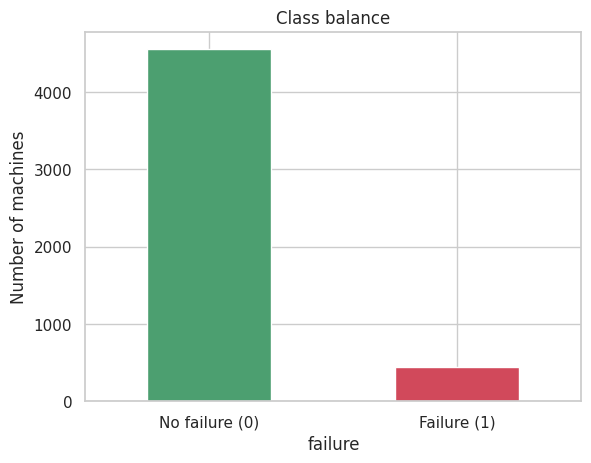

In [4]:
counts = df["failure"].value_counts()
print(counts)
print(f"\nFailure rate: {df['failure'].mean():.1%}")

counts.plot(kind="bar", color=["#4C9F70", "#D1495B"])
plt.xticks([0, 1], ["No failure (0)", "Failure (1)"], rotation=0)
plt.title("Class balance"); plt.ylabel("Number of machines"); plt.show()

**Takeaway:** only about **9%** of machines fail. This is called an *imbalanced* dataset. A lazy model that always says "no failure" would be ~91% accurate but would catch **zero** failures. So accuracy alone can't be trusted here.

### Do failed machines look different?

/tmp/ipykernel_121/3573078706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="failure", y=col, ax=ax, palette=["#4C9F70", "#D1495B"])
/tmp/ipykernel_121/3573078706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="failure", y=col, ax=ax, palette=["#4C9F70", "#D1495B"])
/tmp/ipykernel_121/3573078706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="failure", y=col, ax=ax, palette=["#4C9F70", "#D1495B"])
/tmp/ipykernel_121/3573078706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is

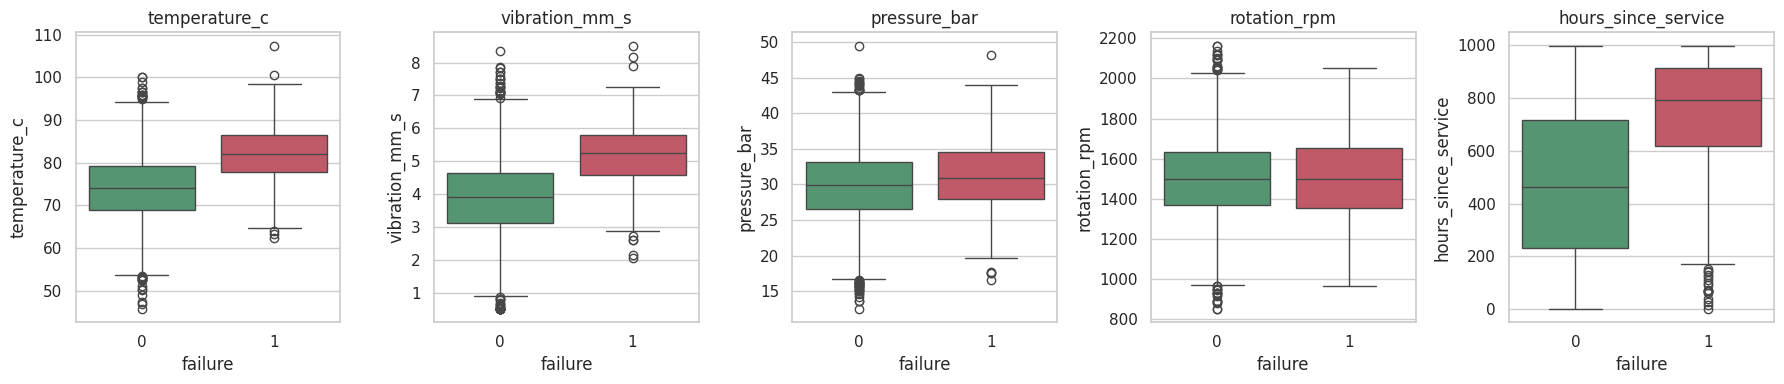

In [5]:
features = ["temperature_c", "vibration_mm_s", "pressure_bar", "rotation_rpm", "hours_since_service"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, features):
    sns.boxplot(data=df, x="failure", y=col, ax=ax, palette=["#4C9F70", "#D1495B"])
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Takeaway:** failed machines (right box in each plot) tend to run hotter, vibrate more, and have gone longer without service. The model's job is to learn this pattern automatically.

## Step 4 — Split into training and test data

- **Training set (80%)** — the model learns from this.
- **Test set (20%)** — hidden from the model; used only at the end to check how it does on machines it has *never seen*.

`stratify=y` keeps the same failure % in both sets, which is important when failures are rare.

In [6]:
X = df[features]
y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Training machines:", len(X_train), "| failure rate:", round(y_train.mean(), 3))
print("Test machines    :", len(X_test),  "| failure rate:", round(y_test.mean(), 3))

Training machines: 4000 | failure rate: 0.089
Test machines    : 1000 | failure rate: 0.089


## Step 5 — Train two models

1. **Logistic Regression** — a simple, easy-to-explain baseline.
2. **Random Forest** — many decision trees voting together; handles more complex patterns.

Because failures are rare, I use `class_weight="balanced"` so the model pays extra attention to the failure cases instead of ignoring them.

In [7]:
# Logistic Regression needs features on the same scale, so we scale first
log_reg = make_pipeline(StandardScaler(),
                        LogisticRegression(class_weight="balanced", max_iter=1000))
log_reg.fit(X_train, y_train)

rand_forest = RandomForestClassifier(n_estimators=200, max_depth=6,
                                     class_weight="balanced", random_state=42)
rand_forest.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## Step 6 — Evaluate on the test set

| Metric | Question it answers |
|---|---|
| **Accuracy** | Out of all machines, how many did we classify correctly? |
| **Precision** | When we predict *failure*, how often are we right? (low precision = many false alarms) |
| **Recall** | Of all machines that *really* failed, how many did we catch? (low recall = missed failures) |
| **F1-score** | A single number balancing precision and recall |

In [8]:
def get_scores(model, name):
    pred = model.predict(X_test)
    return {"Model": name,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall":    recall_score(y_test, pred),
            "F1-score":  f1_score(y_test, pred)}

scores = pd.DataFrame([get_scores(log_reg, "Logistic Regression"),
                       get_scores(rand_forest, "Random Forest")]).set_index("Model")
scores.round(3)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.877,0.410,0.865,0.556
Random Forest,0.917,0.524,0.742,0.614


### Confusion matrix — where exactly does each model go right or wrong?

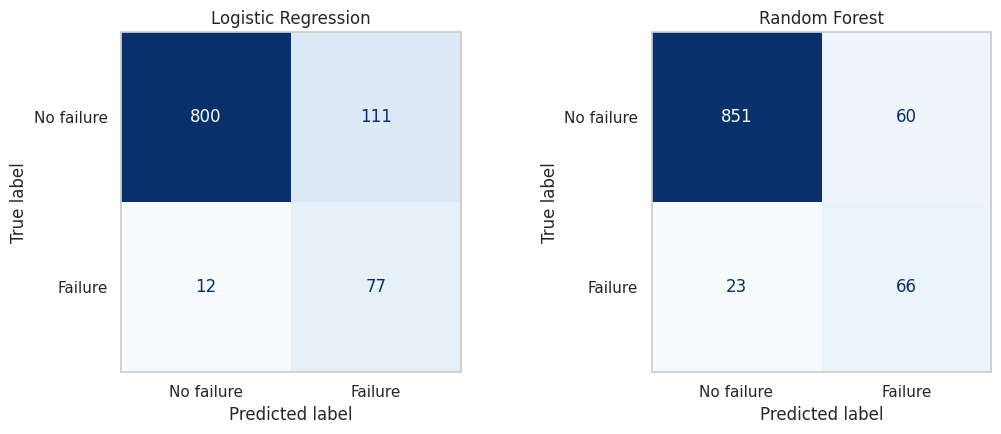

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("Logistic Regression", log_reg), ("Random Forest", rand_forest)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["No failure", "Failure"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.show()

**How to read a confusion matrix** (rows = what really happened, columns = what the model predicted):

| | Predicted: No failure | Predicted: Failure |
|---|---|---|
| **Actually OK** | True Negative ✅ | False Positive ❌ (false alarm — unnecessary inspection) |
| **Actually failed** | False Negative ❌ (**missed failure — the costly one**) | True Positive ✅ (failure caught) |

In [10]:
tn, fp, fn, tp = confusion_matrix(y_test, rand_forest.predict(X_test)).ravel()
print(f"Random Forest on {len(y_test)} unseen machines:")
print(f"  Failures caught (TP)      : {tp}")
print(f"  Failures missed (FN)      : {fn}")
print(f"  False alarms (FP)         : {fp}")
print(f"  Correctly left alone (TN) : {tn}")

Random Forest on 1000 unseen machines:
  Failures caught (TP)      : 66
  Failures missed (FN)      : 23
  False alarms (FP)         : 60
  Correctly left alone (TN) : 851


### What the results tell us
- **Random Forest** has the better balance (F1 ≈ 0.61) and fewer false alarms.
- **Logistic Regression** catches more of the real failures (recall ≈ 0.87) but raises many more false alarms (precision ≈ 0.41).
- This is the classic **precision vs recall trade-off**. In a plant, a missed failure is usually far more expensive than an extra inspection, so recall matters a lot — which is why I look beyond accuracy.

## Step 7 — Which sensors matter most?

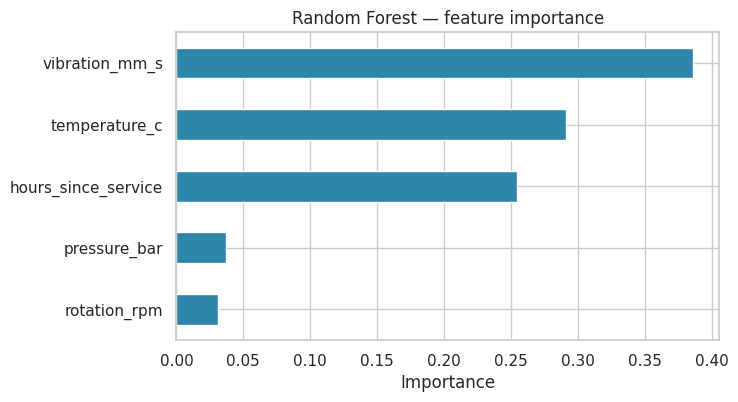

In [11]:
importance = pd.Series(rand_forest.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", color="#2E86AB", figsize=(7, 4))
plt.title("Random Forest — feature importance"); plt.xlabel("Importance"); plt.show()

**Takeaway:** the most important driver is **`vibration_mm_s`**, followed by `temperature_c` and `hours_since_service`. In a real plant this tells engineers which sensors to monitor most closely.

## Step 8 — Use the model on new machines

In [12]:
new_machines = pd.DataFrame({
    "temperature_c":       [72.0, 88.0, 80.0],
    "vibration_mm_s":      [3.5,  6.5,  4.5],
    "pressure_bar":        [29.0, 33.0, 30.0],
    "rotation_rpm":        [1500, 1550, 1480],
    "hours_since_service": [150,  950,  600],
})
new_machines["failure_probability"] = rand_forest.predict_proba(new_machines[features])[:, 1].round(2)
new_machines["prediction"] = rand_forest.predict(new_machines[features])
new_machines

,temperature_c,vibration_mm_s,pressure_bar,rotation_rpm,hours_since_service,failure_probability,prediction
0,72.0,3.5,29.0,1500,150,0.01,0
1,88.0,6.5,33.0,1550,950,0.97,1
2,80.0,4.5,30.0,1480,600,0.38,0


---
# 🎤 Interview Cheat Sheet

## 60-second pitch
> "I built a predictive-maintenance model that predicts whether a machine will fail from sensor readings like temperature, vibration and hours since last service. It's a binary classification problem on an imbalanced dataset — only about 9% of machines fail. I split the data 80/20 with stratification, trained Logistic Regression as a baseline and a Random Forest, and evaluated them on unseen data using accuracy, precision, recall, F1 and a confusion matrix. The Random Forest performed best with an F1 of about 0.61, catching 66 of the 89 failures in the test set. Accuracy alone was misleading, since a model that always says 'no failure' would already score about 91%, so I focused on recall and precision, because missing a real failure is much costlier than a false alarm."

## Likely questions & simple answers

**Why not just use accuracy?**
Because only ~9% of machines fail. A model that always predicts "no failure" gets ~91% accuracy but catches no failures. Recall and precision tell the real story.

**Explain precision and recall in one line each.**
Precision: *of the machines I flagged, how many really failed?* Recall: *of the machines that really failed, how many did I flag?*

**What is a confusion matrix?**
A 2×2 table of correct and wrong predictions: true/false positives and true/false negatives. It shows *which kind* of mistake the model makes.

**Which matters more here — precision or recall?**
Usually recall, because a missed failure means unplanned downtime. But if inspections are very expensive, you'd want to balance with precision — that's what F1 does.

**Why split into train and test?**
To check the model on data it has never seen. Testing on training data would just reward memorising.

**What does `stratify` do?**
It keeps the same failure percentage in train and test sets, which matters when failures are rare.

**Why Random Forest?**
It combines many decision trees, handles non-linear patterns (like "high temperature *and* high vibration"), and gives feature importance. I used Logistic Regression first as a simple, interpretable baseline to compare against.

**What does `class_weight="balanced"` do?**
It makes mistakes on the rare failure class count more during training, so the model doesn't just ignore failures.

**What is overfitting? Did you check?**
Overfitting is when a model memorises training data and does badly on new data. I evaluate only on a held-out test set and limited the forest depth (`max_depth=6`) to reduce the risk.

**Where did the data come from?**
Be upfront: *"It's simulated sensor data so the project is self-contained, built to mimic real relationships. The pipeline is the same for a real dataset like AI4I 2020, which I'd use next."* Honesty here comes across as maturity.

**How would you improve it?**
Use real data, add cross-validation, tune hyperparameters, try gradient boosting, adjust the decision threshold to favour recall, and use time-series sensor history instead of single snapshots.